# Solutions to Process 4
Investigate the validity of the proposed $\{PPB, \tau_\alpha\}$ system solved for $\{T_e, n_e\}$. Check plasma current.

In [1]:
# Reload Process each time (keep editable install up-to-date)
%load_ext autoreload
%autoreload 2
from IPython.display import clear_output
import process
from process.main import SingleRun
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

Running scipy's SLSQP


## Set up
Same as in `solutions_to_process_2.ipynb`.

## Plasma current
Currently, the plasma current is fixed, which needs to change. Run as before, but include plasma current.

In [16]:
w_fracs = np.linspace(5.0e-6, 1.0e-4, 20)
sol_data = {
    "w": [],
    "tau_e_scaling_hfact": [],
    "te": [],
    "ne": [],
    "pfus": [],
    "he": [],
    "ploss": [],
    "nd_alphas": [],
    "f_nd_alpha_electron": [],
    "ip": [],
}
for w_frac in w_fracs:
    # Solve Process each time after modifying W fraction
    single_run = SingleRun("lt_tau_alpha_sol_IN.DAT")
    process.fortran.impurity_radiation_module.impurity_arr_frac[13] = w_frac
    try:
        # Handle failed runs
        single_run.run()
    except Exception:
        continue
    sol_data["w"].append(w_frac)
    sol_data["tau_e_scaling_hfact"].append(
        process.fortran.physics_variables.t_energy_confinement.item()
    )
    sol_data["te"].append(process.fortran.physics_variables.te.item())
    sol_data["ne"].append(process.fortran.physics_variables.dene.item())
    sol_data["pfus"].append(process.fortran.physics_variables.p_fusion_total_mw.item())
    sol_data["he"].append(process.fortran.physics_variables.fusden_plasma_alpha.item())
    sol_data["ploss"].append(process.fortran.physics_variables.p_plasma_loss_mw.item())
    sol_data["nd_alphas"].append(process.fortran.physics_variables.nd_alphas.item())
    sol_data["f_nd_alpha_electron"].append(
        process.fortran.physics_variables.f_nd_alpha_electron.item()
    )
    sol_data["ip"].append(process.fortran.physics_variables.plasma_current.item())

# Clear the lengthy stdout from multiple process runs
clear_output()

Text(0.5, 0.98, 'Various quantities against W density fraction for $\\{PPB, \\tau_\\alpha\\}$ equations solved for $\\{T_e, n_e\\}$')

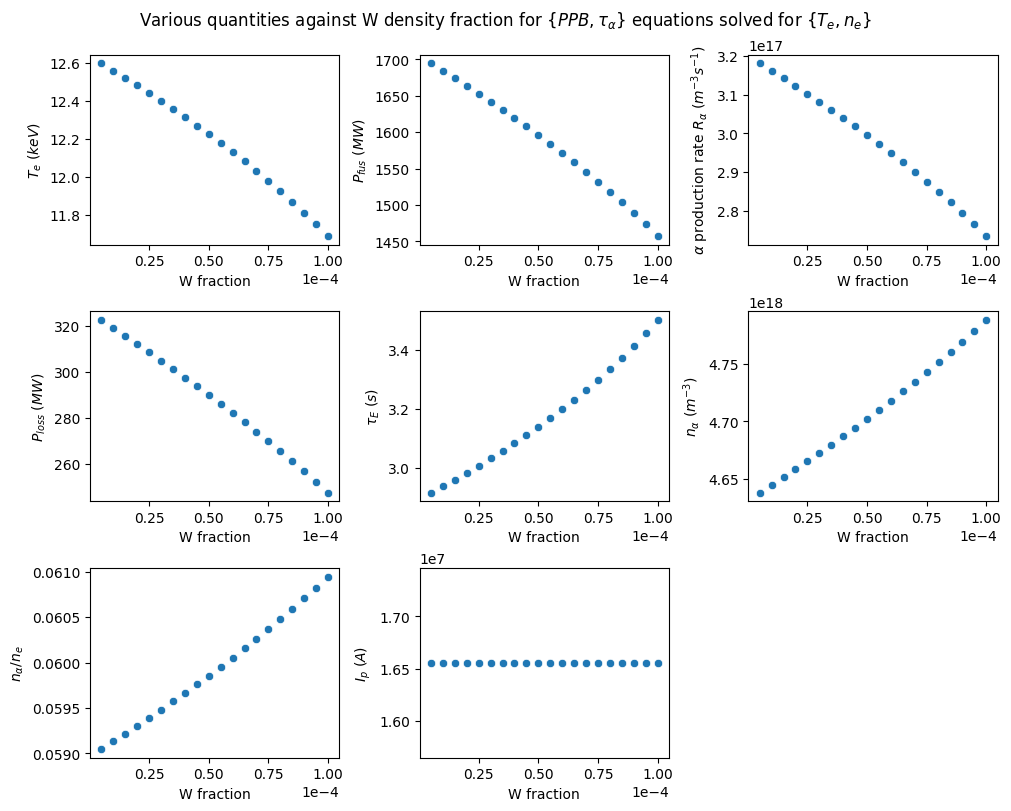

In [17]:
# Plot
sol_df = pd.DataFrame(sol_data)
fig, ax = plt.subplots(ncols=3, nrows=3, layout="constrained")
fig.set_size_inches(10, 8)

# te plot
ax0 = sns.scatterplot(
    data=sol_df,
    x="w",
    y="te",
    ax=ax[0, 0],
)
ax0.set_xlabel("W fraction")
ax0.set_ylabel(r"$T_e$ $(keV)$")
ax0.ticklabel_format(style="sci", axis="x", scilimits=(0, 0))

# pfus plot
ax1 = sns.scatterplot(
    data=sol_df,
    x="w",
    y="pfus",
    ax=ax[0, 1],
)
ax1.set_xlabel("W fraction")
ax1.set_ylabel(r"$P_{fus}$ $(MW)$")
ax1.ticklabel_format(style="sci", axis="x", scilimits=(0, 0))

# alpha plot
ax2 = sns.scatterplot(
    data=sol_df,
    x="w",
    y="he",
    ax=ax[0, 2],
)
ax2.set_xlabel("W fraction")
ax2.set_ylabel(r"$\alpha$ production rate $R_{\alpha}$ $(m^{-3}s^{-1})$")
ax2.ticklabel_format(style="sci", axis="x", scilimits=(0, 0))

# ploss plot
ax3 = sns.scatterplot(
    data=sol_df,
    x="w",
    y="ploss",
    ax=ax[1, 0],
)
ax3.set_xlabel("W fraction")
ax3.set_ylabel(r"$P_{loss}$ $(MW)$")
ax3.ticklabel_format(style="sci", axis="x", scilimits=(0, 0))

# tau_E plot
ax4 = sns.scatterplot(
    data=sol_df,
    x="w",
    y="tau_e_scaling_hfact",
    ax=ax[1, 1],
)
ax4.set_xlabel("W fraction")
ax4.set_ylabel(r"$\tau_E$ $(s)$")
ax4.ticklabel_format(style="sci", axis="x", scilimits=(0, 0))

# nd_alphas plot
ax5 = sns.scatterplot(
    data=sol_df,
    x="w",
    y="nd_alphas",
    ax=ax[1, 2],
)
ax5.set_xlabel("W fraction")
ax5.set_ylabel(r"$n_{\alpha}$ $(m^{-3})$")
ax5.ticklabel_format(style="sci", axis="x", scilimits=(0, 0))

# f_nd_alpha_electron plot
ax6 = sns.scatterplot(
    data=sol_df,
    x="w",
    y="f_nd_alpha_electron",
    ax=ax[2, 0],
)
ax6.set_xlabel("W fraction")
ax6.set_ylabel(r"$n_{\alpha}/n_{e}$")
ax6.ticklabel_format(style="sci", axis="x", scilimits=(0, 0))

# plasma current plot
ax7 = sns.scatterplot(
    data=sol_df,
    x="w",
    y="ip",
    ax=ax[2, 1],
)
ax7.set_xlabel("W fraction")
ax7.set_ylabel(r"$I_p$ $(A)$")
ax7.ticklabel_format(style="sci", axis="x", scilimits=(0, 0))

ax[2, 2].axis("off")

fig.suptitle(
    r"Various quantities against W density fraction for $\{PPB, \tau_\alpha\}$ equations solved for $\{T_e, n_e\}$"
)

Text(0.5, 1.0, '$I_p$ against W fraction for $\\{PPB, \\tau_\\alpha\\}$ equations solved for $\\{T_e, n_e\\}$')

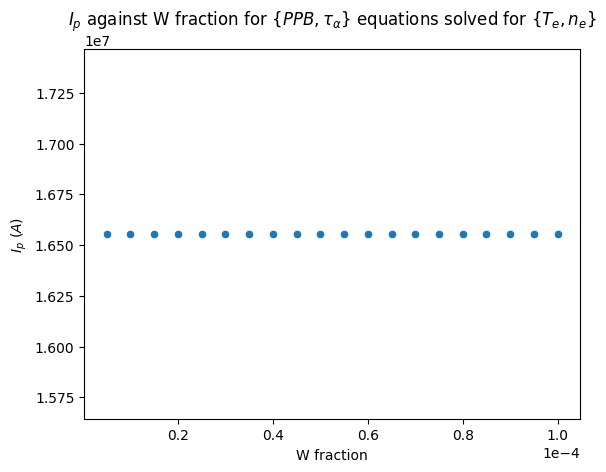

In [21]:
# Plot
sol_df = pd.DataFrame(sol_data)
fig, ax = plt.subplots()
# fig.set_size_inches(10, 8)

# plasma current plot
ax = sns.scatterplot(
    data=sol_df,
    x="w",
    y="ip",
    ax=ax,
)
ax.set_xlabel(r"W fraction")
ax.set_ylabel(r"$I_p$ $(A)$")
ax.ticklabel_format(style="sci", axis="x", scilimits=(0, 0))

ax.set_title(
    r"$I_p$ against W fraction for $\{PPB, \tau_\alpha\}$ equations solved for $\{T_e, n_e\}$"
)

Plasma current is fixed, which should be the case, but the fractions composing it may vary. Try varying something else, such as triangularity.

In [22]:
triangs = np.linspace(0.4, 0.6, 20)
sol_data = {
    "triang": [],
    "tau_e_scaling_hfact": [],
    "te": [],
    "ne": [],
    "pfus": [],
    "he": [],
    "ploss": [],
    "nd_alphas": [],
    "f_nd_alpha_electron": [],
    "ip": [],
}
for triang in triangs:
    # Solve Process each time after modifying W fraction
    single_run = SingleRun("lt_tau_alpha_sol_IN.DAT")
    process.fortran.physics_variables.triang = triang
    try:
        # Handle failed runs
        single_run.run()
    except Exception:
        continue
    sol_data["triang"].append(triang)
    sol_data["tau_e_scaling_hfact"].append(
        process.fortran.physics_variables.t_energy_confinement.item()
    )
    sol_data["te"].append(process.fortran.physics_variables.te.item())
    sol_data["ne"].append(process.fortran.physics_variables.dene.item())
    sol_data["pfus"].append(process.fortran.physics_variables.p_fusion_total_mw.item())
    sol_data["he"].append(process.fortran.physics_variables.fusden_plasma_alpha.item())
    sol_data["ploss"].append(process.fortran.physics_variables.p_plasma_loss_mw.item())
    sol_data["nd_alphas"].append(process.fortran.physics_variables.nd_alphas.item())
    sol_data["f_nd_alpha_electron"].append(
        process.fortran.physics_variables.f_nd_alpha_electron.item()
    )
    sol_data["ip"].append(process.fortran.physics_variables.plasma_current.item())

# Clear the lengthy stdout from multiple process runs
clear_output()

Text(0.5, 0.98, 'Various quantities against W density fraction for $\\{PPB, \\tau_\\alpha\\}$ equations solved for $\\{T_e, n_e\\}$')

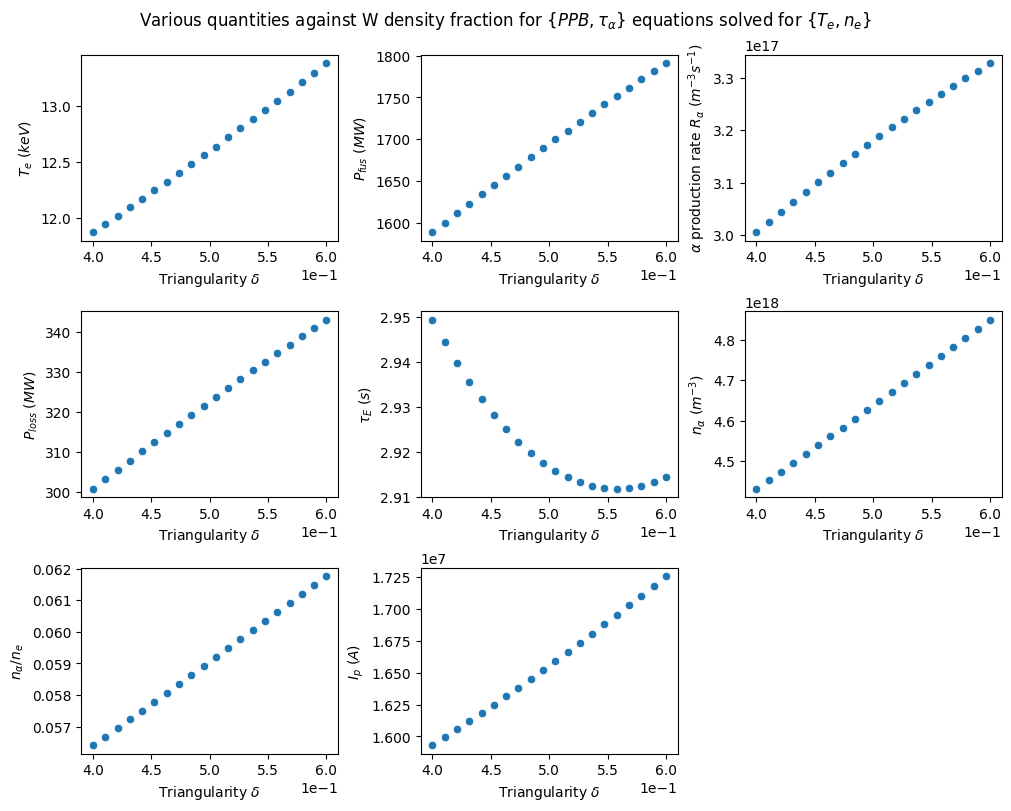

In [23]:
# Plot
sol_df = pd.DataFrame(sol_data)
fig, ax = plt.subplots(ncols=3, nrows=3, layout="constrained")
fig.set_size_inches(10, 8)

# te plot
ax0 = sns.scatterplot(
    data=sol_df,
    x="triang",
    y="te",
    ax=ax[0, 0],
)
ax0.set_xlabel(r"Triangularity $\delta$")
ax0.set_ylabel(r"$T_e$ $(keV)$")
ax0.ticklabel_format(style="sci", axis="x", scilimits=(0, 0))

# pfus plot
ax1 = sns.scatterplot(
    data=sol_df,
    x="triang",
    y="pfus",
    ax=ax[0, 1],
)
ax1.set_xlabel(r"Triangularity $\delta$")
ax1.set_ylabel(r"$P_{fus}$ $(MW)$")
ax1.ticklabel_format(style="sci", axis="x", scilimits=(0, 0))

# alpha plot
ax2 = sns.scatterplot(
    data=sol_df,
    x="triang",
    y="he",
    ax=ax[0, 2],
)
ax2.set_xlabel(r"Triangularity $\delta$")
ax2.set_ylabel(r"$\alpha$ production rate $R_{\alpha}$ $(m^{-3}s^{-1})$")
ax2.ticklabel_format(style="sci", axis="x", scilimits=(0, 0))

# ploss plot
ax3 = sns.scatterplot(
    data=sol_df,
    x="triang",
    y="ploss",
    ax=ax[1, 0],
)
ax3.set_xlabel(r"Triangularity $\delta$")
ax3.set_ylabel(r"$P_{loss}$ $(MW)$")
ax3.ticklabel_format(style="sci", axis="x", scilimits=(0, 0))

# tau_E plot
ax4 = sns.scatterplot(
    data=sol_df,
    x="triang",
    y="tau_e_scaling_hfact",
    ax=ax[1, 1],
)
ax4.set_xlabel(r"Triangularity $\delta$")
ax4.set_ylabel(r"$\tau_E$ $(s)$")
ax4.ticklabel_format(style="sci", axis="x", scilimits=(0, 0))

# nd_alphas plot
ax5 = sns.scatterplot(
    data=sol_df,
    x="triang",
    y="nd_alphas",
    ax=ax[1, 2],
)
ax5.set_xlabel(r"Triangularity $\delta$")
ax5.set_ylabel(r"$n_{\alpha}$ $(m^{-3})$")
ax5.ticklabel_format(style="sci", axis="x", scilimits=(0, 0))

# f_nd_alpha_electron plot
ax6 = sns.scatterplot(
    data=sol_df,
    x="triang",
    y="f_nd_alpha_electron",
    ax=ax[2, 0],
)
ax6.set_xlabel(r"Triangularity $\delta$")
ax6.set_ylabel(r"$n_{\alpha}/n_{e}$")
ax6.ticklabel_format(style="sci", axis="x", scilimits=(0, 0))

# plasma current plot
ax7 = sns.scatterplot(
    data=sol_df,
    x="triang",
    y="ip",
    ax=ax[2, 1],
)
ax7.set_xlabel(r"Triangularity $\delta$")
ax7.set_ylabel(r"$I_p$ $(A)$")
ax7.ticklabel_format(style="sci", axis="x", scilimits=(0, 0))

ax[2, 2].axis("off")

fig.suptitle(
    r"Various quantities against W density fraction for $\{PPB, \tau_\alpha\}$ equations solved for $\{T_e, n_e\}$"
)

Text(0.5, 1.0, '$I_p$ against $\\delta$ for $\\{PPB, \\tau_\\alpha\\}$ equations solved for $\\{T_e, n_e\\}$')

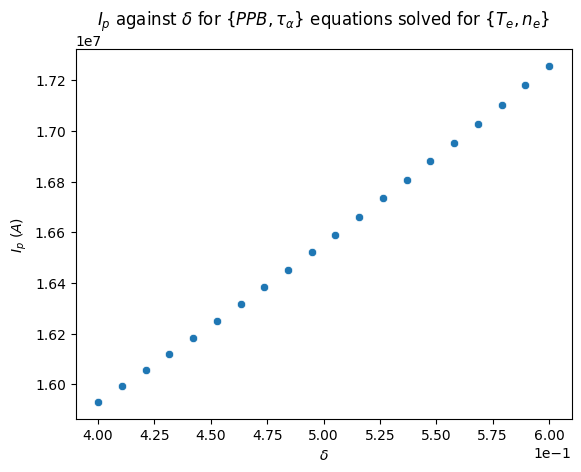

In [25]:
# Plot
sol_df = pd.DataFrame(sol_data)
fig, ax = plt.subplots()
# fig.set_size_inches(10, 8)

# plasma current plot
ax = sns.scatterplot(
    data=sol_df,
    x="triang",
    y="ip",
    ax=ax,
)
ax.set_xlabel(r"$\delta$")
ax.set_ylabel(r"$I_p$ $(A)$")
ax.ticklabel_format(style="sci", axis="x", scilimits=(0, 0))

ax.set_title(
    r"$I_p$ against $\delta$ for $\{PPB, \tau_\alpha\}$ equations solved for $\{T_e, n_e\}$"
)

I_p changes with triangularity, but not W fraction. Check change with q95:

In [ ]:
q95s = np.linspace(3.0, 4.0, 20)
sol_data = {
    "q95": [],
    "ip": [],
}
for q95 in q95s:
    # Solve Process each time after modifying W fraction
    single_run = SingleRun("lt_tau_alpha_sol_IN.DAT")
    process.fortran.physics_variables.q95 = q95
    try:
        # Handle failed runs
        single_run.run()
    except Exception:
        continue
    sol_data["q95"].append(q95)
    sol_data["ip"].append(process.fortran.physics_variables.plasma_current.item())

# Clear the lengthy stdout from multiple process runs
clear_output()

Text(0.5, 1.0, '$I_p$ against $q_{95}$ for $\\{PPB, \\tau_\\alpha\\}$ equations solved for $\\{T_e, n_e\\}$')

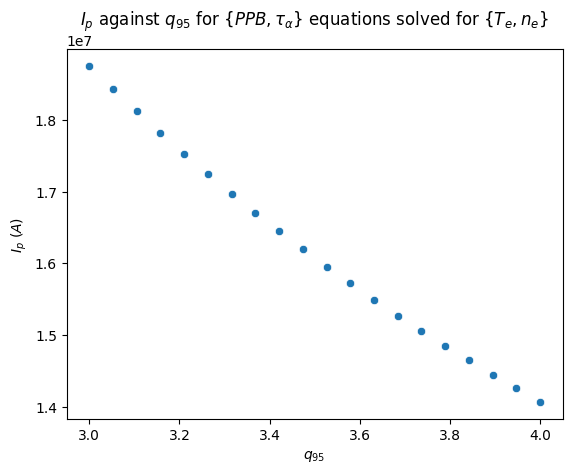

In [14]:
# Plot
sol_df = pd.DataFrame(sol_data)
fig, ax = plt.subplots()
# fig.set_size_inches(10, 8)

# plasma current plot
ax = sns.scatterplot(
    data=sol_df,
    x="q95",
    y="ip",
    ax=ax,
)
ax.set_xlabel(r"$q_{95}$")
ax.set_ylabel(r"$I_p$ $(A)$")
ax.ticklabel_format(style="sci", axis="x", scilimits=(0, 0))

ax.set_title(
    r"$I_p$ against $q_{95}$ for $\{PPB, \tau_\alpha\}$ equations solved for $\{T_e, n_e\}$"
)